# 02 · Forecast tournament & backtesting

**Goal:** produce a 12-month rolling forecast for each of the 27 P&L lines, prove it is more accurate than the static budget, and attach an *expected range* to every forecast so that surprises can be flagged.

**How we test fairly:** we replay the past. For each of the last 24 month-ends we pretend it is the latest close, train only on data available then, forecast 12 months ahead, and later score those forecasts against what actually happened (a *rolling-origin backtest*). The model chosen for each line at each month-end is the one with the best track record *up to that date*, so the accuracy numbers are genuinely out of sample.

The heavy lifting runs in the pipeline (`python -m fpa.pipeline run`). This notebook reads the results from `data/marts/`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from fpa import viz
from fpa.viz import ROLE, month_axis, pct_axis, plt, usd, usd_axis

viz.use_style()
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MARTS = ROOT / "data" / "marts"
read = lambda name: pd.read_parquet(MARTS / f"{name}.parquet")
meta = json.loads((MARTS / "run_metadata.json").read_text())
AS_OF = pd.Period(meta["as_of"], "M")
print(f"Forecast as of {AS_OF} close")

Forecast as of 2026-08 close


## 1. The contenders

| Model | Idea in one line | Why it's in the race |
|---|---|---|
| **Naive** | next month = this month | the "no-brainer" baseline |
| **SeasonalNaive** | next month = same month last year | captures seasonality, ignores growth |
| **ARRRunRate** | revenue = ARR / 12, rolled forward at recent growth | how FP&A teams forecast subscription revenue (revenue line only) |
| **AutoETS** | exponential smoothing: recent months weigh more; trend and seasonality picked automatically | classic, robust, explainable |
| **AutoARIMA** | models each month as a function of recent months and errors | classic statistical benchmark |
| **LightGBM** | one gradient-boosted model learned across all lines from lags, calendar and the **headcount plan** | machine learning that can use business drivers |

**Rule for picking a champion:** lowest WAPE (weighted absolute % error) wins. If two models are within 1%, the simpler one wins.

**Before training,** one-off spikes are dampened with a robust seasonal decomposition. This is the statistical version of "normalising" actuals, so a legal settlement doesn't get forecast to recur.

In [2]:
lb = read("leaderboard")
series_meta = read("series_meta")
actual_size = read("accuracy_by_series").set_index("unique_id")["actual_12m_usd"]
overall = lb[lb["bucket"] == "All horizons"].pivot(index="unique_id", columns="model", values="wape")
order = ["Naive", "SeasonalNaive", "ARRRunRate", "AutoETS", "AutoARIMA", "LightGBM"]
weighted = {m: np.average(overall[m].dropna(), weights=actual_size.reindex(overall[m].dropna().index)) for m in order}
pd.Series(weighted, name="Dollar-weighted WAPE (24 origins, 1-12 months ahead)").map("{:.1%}".format).to_frame()

,"Dollar-weighted WAPE (24 origins, 1-12 months ahead)"
Naive,15.1%
SeasonalNaive,17.9%
ARRRunRate,3.8%
AutoETS,7.6%
AutoARIMA,8.4%
LightGBM,8.7%


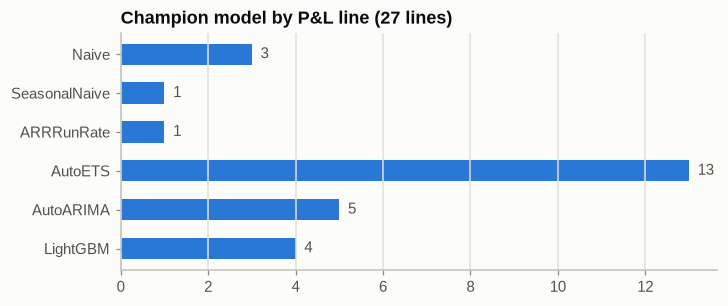

fs_line,department,champion,champion_wape
Commissions,Sales,LightGBM,21.0%
Contractors,Engineering,AutoETS,20.1%
Contractors,G&A,AutoETS,51.7%
Contractors,Professional Services,AutoETS,18.4%
Depreciation,G&A,AutoETS,1.5%
Facilities,G&A,Naive,2.0%
Hosting,Cloud Operations,AutoETS,13.8%
Marketing Programs,Marketing,AutoETS,12.1%
Personnel,Cloud Operations,Naive,7.7%
Personnel,Customer Success,AutoETS,8.7%


In [3]:
champs = read("champions")
mix = champs["champion"].value_counts().reindex(order).dropna().astype(int)
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(mix.index[::-1], mix.values[::-1], height=0.55, color=viz.SERIES[0])
for y, v in enumerate(mix.values[::-1]):
    ax.text(v + 0.2, y, str(v), va="center", color=viz.INK_2)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Champion model by P&L line (27 lines)")
plt.show()
champs[["fs_line", "department", "champion", "champion_wape"]].sort_values(["fs_line", "department"]).style.format({"champion_wape": "{:.1%}"}).hide(axis="index")

**Read-out:** no single model wins everywhere, which is why a tournament beats picking one favourite.
- Smooth lines like payroll and depreciation go to exponential smoothing or ARIMA.
- Very stable lines like rent go to **Naive**. Nothing beats "same as last month" for a fixed lease.
- **Subscription revenue** goes to the FP&A driver method (ARR run-rate).
- LightGBM wins some personnel and commission lines, where the headcount plan and cross-line patterns help.

## 2. Rolling forecast vs static budget (last 12 closed months, out of sample)

In [4]:
s = read("accuracy_summary").iloc[0]
print(f"Window {s['window_start']} to {s['window_end']}")
print(f"  Rolling forecast WAPE (1-12 months ahead): {s['rolling_forecast_wape']:.1%}")
print(f"  Rolling forecast WAPE (1 month ahead):     {s['rolling_forecast_1m_wape']:.1%}")
print(f"  Static budget WAPE:                        {s['budget_wape']:.1%}")
print(f"  Seasonal-naive WAPE:                       {s['seasonal_naive_wape']:.1%}")
print(f"  -> rolling forecast is {s['improvement_vs_budget']:.0%} more accurate than the budget")

Window 2025-09 to 2026-08
  Rolling forecast WAPE (1-12 months ahead): 8.3%
  Rolling forecast WAPE (1 month ahead):     6.6%
  Static budget WAPE:                        10.3%
  Seasonal-naive WAPE:                       18.9%
  -> rolling forecast is 20% more accurate than the budget


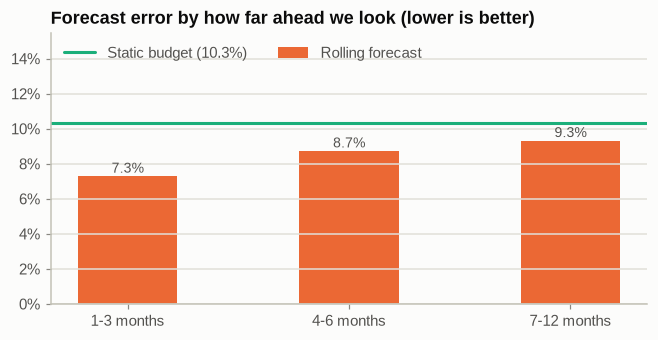

In [5]:
byh = read("accuracy_by_horizon")
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(byh))
budget_wape = byh["budget_wape"].iloc[0]
ax.bar(x, byh["rolling_forecast_wape"], width=0.45, color=ROLE["forecast"], label="Rolling forecast")
ax.axhline(budget_wape, color=ROLE["budget"], linewidth=2, label=f"Static budget ({budget_wape:.1%})")
for xi, v in zip(x, byh["rolling_forecast_wape"]):
    ax.text(xi, v + 0.002, f"{v:.1%}", ha="center", color=viz.INK_2, fontsize=9)
ax.set_xticks(x, byh["bucket"]); pct_axis(ax); ax.set_ylim(0, budget_wape * 1.5)
ax.set_title("Forecast error by how far ahead we look (lower is better)")
ax.legend(loc="upper left", ncol=2)
plt.show()

In [6]:
acc = read("accuracy_by_series").sort_values("actual_12m_usd", ascending=False)
acc["winner"] = np.where(acc["rolling_forecast_wape"] < acc["budget_wape"], "Forecast", "Budget")
print(f"Rolling forecast beats budget on {(acc['winner'] == 'Forecast').sum()} of {len(acc)} lines, "
      f"covering {acc.loc[acc['winner'] == 'Forecast', 'actual_12m_usd'].sum() / acc['actual_12m_usd'].sum():.0%} of P&L dollars")
acc[["fs_line", "department", "actual_12m_usd", "rolling_forecast_wape", "budget_wape", "winner"]].head(12).style.format(
    {"actual_12m_usd": lambda v: usd(v), "rolling_forecast_wape": "{:.1%}", "budget_wape": "{:.1%}"}).hide(axis="index")

Rolling forecast beats budget on 15 of 27 lines, covering 88% of P&L dollars


fs_line,department,actual_12m_usd,rolling_forecast_wape,budget_wape,winner
Subscription Revenue,Company,$62.7M,5.5%,6.2%,Forecast
Personnel,Engineering,$16.9M,3.0%,8.2%,Forecast
Hosting,Cloud Operations,$9.8M,16.2%,17.6%,Forecast
Personnel,Sales,$8.6M,5.9%,7.4%,Forecast
Personnel,G&A,$5.7M,4.4%,8.6%,Forecast
Services Revenue,Company,$5.6M,16.2%,22.0%,Forecast
Personnel,Marketing,$3.8M,6.1%,10.0%,Forecast
Marketing Programs,Marketing,$3.7M,14.7%,11.6%,Budget
Personnel,Customer Success,$3.0M,7.2%,6.9%,Budget
Personnel,Product,$2.5M,4.2%,7.5%,Forecast


## 3. How the forecast evolves: vintages

Each month-end produces a new forecast *vintage*. Below are two lines with very different behaviour, each showing the actuals, the budget and the forecasts made at three month-ends. Subscription revenue grows steadily. Marketing is seasonal, with peaks for the May trade show and the October conference.

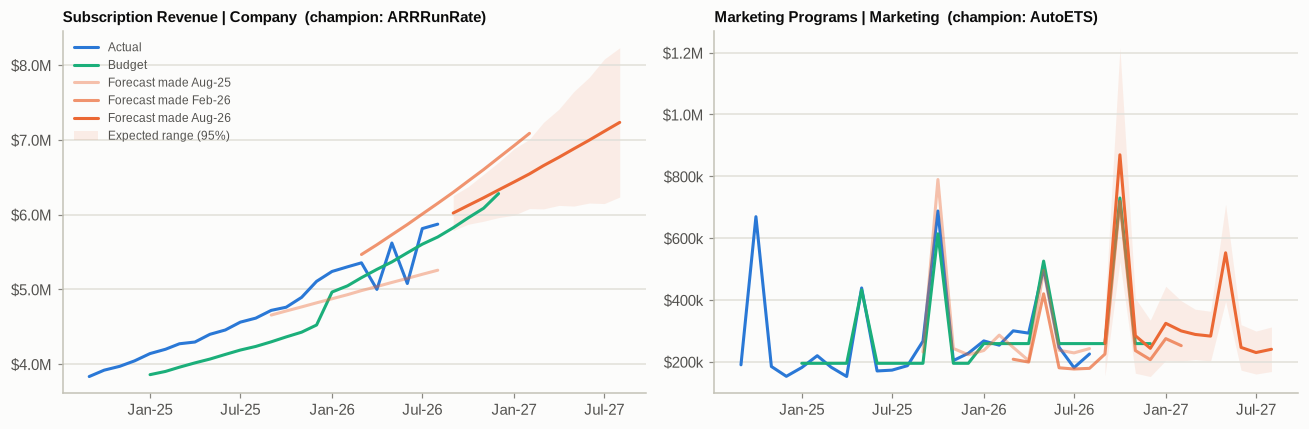

In [7]:
vint = read("forecast_vintages")
pnl = read("fct_monthly_pnl"); pnl["unique_id"] = pnl["fs_line"] + " | " + pnl["department"]
bud = read("fct_budget_monthly"); bud["unique_id"] = bud["fs_line"] + " | " + bud["department"]
for d in (pnl, bud):
    d["ds"] = pd.PeriodIndex(d["period"], freq="M").to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["Subscription Revenue | Company", "Marketing Programs | Marketing"]):
    v = vint[(vint["unique_id"] == name) & vint["is_champion"]]
    a = pnl[(pnl["unique_id"] == name) & (pnl["ds"] >= "2024-09-01")]
    b = bud[(bud["unique_id"] == name) & (bud["ds"] >= "2025-01-01")]
    ax.plot(a["ds"], a["actual_usd"], color=ROLE["actual"], label="Actual")
    ax.plot(b["ds"], b["budget_usd"], color=ROLE["budget"], label="Budget")
    origins = sorted(v["origin"].unique())
    for alpha, o in zip((0.4, 0.7, 1.0), (origins[0], origins[len(origins) // 2], origins[-1])):
        f = v[v["origin"] == o]
        ax.plot(f["ds"], f["yhat"], color=ROLE["forecast"], alpha=alpha, label=f"Forecast made {pd.Timestamp(o):%b-%y}")
    live = v[v["origin"] == origins[-1]]
    ax.fill_between(live["ds"], live["lo95"], live["hi95"], color=ROLE["forecast"], alpha=0.10, linewidth=0, label="Expected range (95%)")
    usd_axis(ax); month_axis(ax)
    ax.set_title(f"{name}  (champion: {live['model'].iloc[0]})", fontsize=10)
axes[0].legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

The **expected range** comes from each champion's own track record. It is the spread of its past errors at that horizon, measured against *cleaned* actuals, so it describes normal business variation. The variance-flagging step ([notebook 03](03_variance_analysis.ipynb)) treats an actual outside this range as a surprise.

## 4. What outlier cleaning does

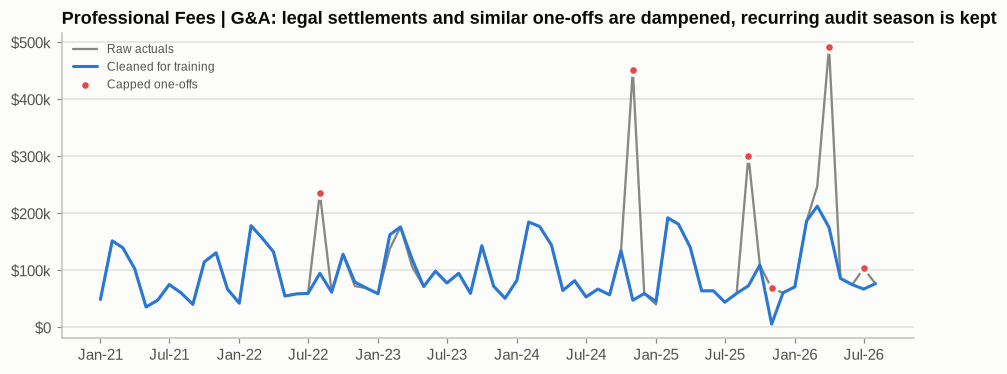

In [8]:
clean = read("cleaned_history")
raw = read("fct_monthly_pnl")
raw["unique_id"] = raw["fs_line"] + " | " + raw["department"]
raw["ds"] = pd.PeriodIndex(raw["period"], freq="M").to_timestamp()
name = "Professional Fees | G&A"
c = clean[clean["unique_id"] == name].merge(raw[raw["unique_id"] == name][["ds", "actual_usd"]], on="ds")
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(c["ds"], c["actual_usd"], color=viz.MUTED, linewidth=1.5, label="Raw actuals")
ax.plot(c["ds"], c["y_clean"], color=ROLE["actual"], label="Cleaned for training")
capped = c[(c["actual_usd"] - c["y_clean"]).abs() > 0.25 * c["y_clean"].abs().clip(lower=10_000)]
ax.scatter(capped["ds"], capped["actual_usd"], s=40, color=viz.SERIES[7], edgecolor=viz.SURFACE, linewidth=2, zorder=3, label="Capped one-offs")
usd_axis(ax); month_axis(ax); ax.legend(loc="upper left", fontsize=8)
ax.set_title(f"{name}: legal settlements and similar one-offs are dampened, recurring audit season is kept")
plt.show()

## 5. An honest limitation: forecast bias

A good analyst reports the weak spots too. The chart below shows the average % by which the champion forecasts miss, by horizon.

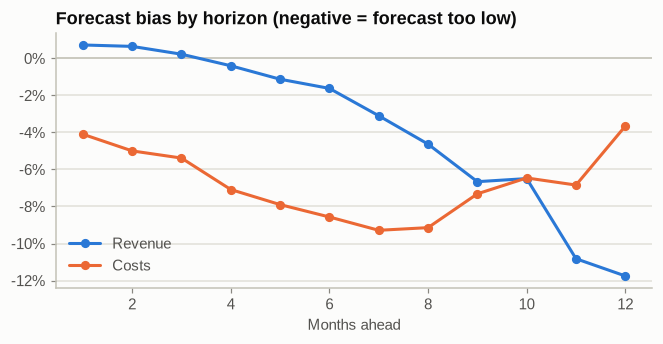

In [9]:
v = vint[vint["is_champion"] & vint["y"].notna() & (vint["origin"] >= (AS_OF - 12).to_timestamp()) & (vint["origin"] < AS_OF.to_timestamp())]
v = v.merge(series_meta[["unique_id", "account_type"]], on="unique_id")
v["group"] = np.where(v["account_type"] == "Revenue", "Revenue", "Costs")
bias = v.groupby(["group", "horizon"]).apply(lambda g: (g["yhat"] - g["y"]).sum() / g["y"].sum(), include_groups=False).unstack(0)
fig, ax = plt.subplots(figsize=(7, 3))
ax.axhline(0, color=viz.AXIS, linewidth=1)
ax.plot(bias.index, bias["Revenue"], marker="o", markersize=5, color=viz.SERIES[0], label="Revenue")
ax.plot(bias.index, bias["Costs"], marker="o", markersize=5, color=viz.SERIES[1], label="Costs")
pct_axis(ax); ax.set_xlabel("Months ahead"); ax.legend()
ax.set_title("Forecast bias by horizon (negative = forecast too low)")
plt.show()

**What the chart says:**
- **Revenue** is essentially unbiased for the next quarter, which is where monthly decisions are made. At 9-12 months it runs low: the mid-2025 price increase kept lifting ARR for a year as contracts renewed, and a trailing growth rate cannot anticipate a pricing decision. A real FP&A team would overlay the pricing plan on the forecast.
- **Costs** are under-forecast by 4-9%. Roughly 40% of that gap comes from one-off cost spikes (settlements, unapproved spend) that no model can see coming, which is exactly what the variance flags are for. The rest is a **regime change**: the company accelerated hiring in 2026, and models that learn only from history lag behind. LightGBM, which sees the hiring plan, shows the smallest cost bias.

**Next steps in a real deployment:** add a driver-based personnel model (headcount plan × fully loaded cost per head), overlay known pricing and hiring decisions, or apply a bias correction based on the trailing 12-month tracking signal.

## 6. What LightGBM pays attention to

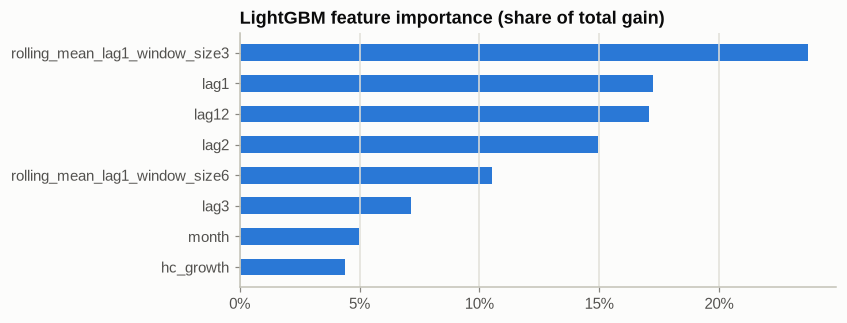

In [10]:
imp = read("lgb_importance").sort_values("gain_share")
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(imp["feature"], imp["gain_share"], height=0.55, color=viz.SERIES[0])
pct_axis(ax, "x"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("LightGBM feature importance (share of total gain)")
plt.show()

Recent run-rate (the 3-month rolling mean and last month) and the same month last year dominate. The headcount-plan growth feature contributes modestly, but it is the only forward-looking business input in the model.

## 7. The deliverable: full-year landing estimate

In [11]:
o = read("fy_outlook")
o["group"] = np.where(o["account_type"] == "Revenue", "Revenue", "Costs")
t = o.groupby("group")[["ytd_actual_usd", "remaining_forecast_usd", "fy_outlook_usd", "fy_budget_usd"]].sum()
t.loc["Operating income"] = t.loc["Revenue"] - t.loc["Costs"]
t["outlook_vs_budget"] = t["fy_outlook_usd"] - t["fy_budget_usd"]
print(f"FY{o['fiscal_year'].iloc[0]}: {o['months_actual'].iloc[0]} months actual + {12 - o['months_actual'].iloc[0]} months forecast")
t.style.format(lambda v: usd(v))

FY2026: 8 months actual + 4 months forecast


,ytd_actual_usd,remaining_forecast_usd,fy_outlook_usd,fy_budget_usd,outlook_vs_budget
group,,,,,
Costs,$52.7M,$27.0M,$79.8M,$81.9M,-$2.1M
Revenue,$47.1M,$26.7M,$73.9M,$72.8M,$1.1M
Operating income,-$5.6M,-$272k,-$5.9M,-$9.1M,$3.2M


### Key takeaways
1. A **model tournament** with a simplicity tie-break picks a sensible champion per line, including the FP&A-native ARR driver model for revenue.
2. Out of sample, the rolling forecast is **more accurate than the static budget**, and most of all in the next quarter, which is when decisions get made.
3. Every forecast carries an **expected range** learned from its own track record. That range powers the surprise test in variance flagging.
4. Known limitation: costs are under-forecast during a hiring acceleration. It is documented, and a fix is proposed.